In [1]:
import tensorflow as tf

print("TensorFlow:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
from pathlib import Path

input_root = Path("/kaggle/input/datasets/yuriyrizoboyev/traffic-sign-project-code/Traffic_Sign_Kaggle")

for path in input_root.iterdir():
    print(path)

/kaggle/input/datasets/yuriyrizoboyev/traffic-sign-project-code/Traffic_Sign_Kaggle/train_custom_cnn.py
/kaggle/input/datasets/yuriyrizoboyev/traffic-sign-project-code/Traffic_Sign_Kaggle/config.py
/kaggle/input/datasets/yuriyrizoboyev/traffic-sign-project-code/Traffic_Sign_Kaggle/custom_cnn_model.py
/kaggle/input/datasets/yuriyrizoboyev/traffic-sign-project-code/Traffic_Sign_Kaggle/data_pipeline.py
/kaggle/input/datasets/yuriyrizoboyev/traffic-sign-project-code/Traffic_Sign_Kaggle/evaluate_custom_cnn.py
/kaggle/input/datasets/yuriyrizoboyev/traffic-sign-project-code/Traffic_Sign_Kaggle/prepared_data


In [3]:
from pathlib import Path

matches = list(Path("/kaggle/input").rglob("Train.csv"))

for match in matches:
    print(match)

/kaggle/input/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign/Train.csv


In [4]:
from pathlib import Path

def find_gtsrb_root() -> Path:
    for train_csv in Path("/kaggle/input").rglob("Train.csv"):
        candidate = train_csv.parent

        if (
            (candidate / "Test.csv").exists()
            and (candidate / "Train").is_dir()
            and (candidate / "Test").is_dir()
        ):
            return candidate

    raise FileNotFoundError("GTSRB dataset root was not found.")

DATASET_ROOT = find_gtsrb_root()
print("GTSRB root:", DATASET_ROOT)

GTSRB root: /kaggle/input/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign


In [5]:
from pathlib import Path
import shutil

WORK_ROOT = Path("/kaggle/working/traffic_sign_project")
WORK_ROOT.mkdir(parents=True, exist_ok=True)

for path in Path("/kaggle/input").iterdir():
    print(path)

/kaggle/input/datasets


In [6]:
CODE_INPUT = Path("/kaggle/input/datasets/yuriyrizoboyev/traffic-sign-project-code")

In [7]:
for source in CODE_INPUT.rglob("*"):
    if source.is_file():
        relative = source.relative_to(CODE_INPUT)
        destination = WORK_ROOT / relative
        destination.parent.mkdir(parents=True, exist_ok=True)
        shutil.copy2(source, destination)

print("Copied to:", WORK_ROOT)

Copied to: /kaggle/working/traffic_sign_project


In [8]:
from pathlib import Path
import shutil


SOURCE_ROOT = Path(
    "/kaggle/input/datasets/yuriyrizoboyev/"
    "traffic-sign-project-code/Traffic_Sign_Kaggle"
)

DESTINATION_ROOT = Path(
    "/kaggle/working/traffic_sign_project"
)


print("Source exists:", SOURCE_ROOT.exists())
print("Source:", SOURCE_ROOT)


if not SOURCE_ROOT.exists():
    raise FileNotFoundError(
        f"Не найдена исходная папка:\n{SOURCE_ROOT}"
    )

if DESTINATION_ROOT.exists():
    shutil.rmtree(DESTINATION_ROOT)


shutil.copytree(
    SOURCE_ROOT,
    DESTINATION_ROOT,
)


print("\nFiles copied successfully.")
print("Destination:", DESTINATION_ROOT)

Source exists: True
Source: /kaggle/input/datasets/yuriyrizoboyev/traffic-sign-project-code/Traffic_Sign_Kaggle

Files copied successfully.
Destination: /kaggle/working/traffic_sign_project


In [9]:
from pathlib import Path


DESTINATION_ROOT = Path(
    "/kaggle/working/traffic_sign_project"
)


print("Содержимое рабочей папки:\n")


for path in sorted(DESTINATION_ROOT.rglob("*")):
    if path.is_file():
        print(path.relative_to(DESTINATION_ROOT))

Содержимое рабочей папки:

config.py
custom_cnn_model.py
data_pipeline.py
evaluate_custom_cnn.py
prepared_data/excluded_train_duplicates.csv
prepared_data/split_summary.csv
prepared_data/train_manifest.csv
prepared_data/validation_manifest.csv
train_custom_cnn.py


In [10]:
from pathlib import Path


PROJECT_ROOT = Path(
    "/kaggle/working/traffic_sign_project"
)


PREPARED_ROOT = (
    PROJECT_ROOT
    / "prepared_data"
)


DATASET_ROOT = Path(
    "/kaggle/input/datasets/meowmeowmeowmeowmeow/"
    "gtsrb-german-traffic-sign"
)


print("PROJECT_ROOT:")
print(PROJECT_ROOT)

print("\nPREPARED_ROOT:")
print(PREPARED_ROOT)

print("\nDATASET_ROOT:")
print(DATASET_ROOT)

PROJECT_ROOT:
/kaggle/working/traffic_sign_project

PREPARED_ROOT:
/kaggle/working/traffic_sign_project/prepared_data

DATASET_ROOT:
/kaggle/input/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign


In [11]:
required_paths = [
    PROJECT_ROOT / "config.py",
    PROJECT_ROOT / "data_pipeline.py",
    PROJECT_ROOT / "custom_cnn_model.py",
    PROJECT_ROOT / "train_custom_cnn.py",
    PROJECT_ROOT / "evaluate_custom_cnn.py",

    PREPARED_ROOT / "train_manifest.csv",
    PREPARED_ROOT / "validation_manifest.csv",

    DATASET_ROOT / "Train.csv",
    DATASET_ROOT / "Test.csv",
    DATASET_ROOT / "Train",
    DATASET_ROOT / "Test",
]


all_found = True


for path in required_paths:
    if path.exists():
        print("OK:", path)
    else:
        print("NOT FOUND:", path)
        all_found = False


if not all_found:
    raise FileNotFoundError(
        "Some required files are missing."
    )


print("\nAll necessary files found.")

OK: /kaggle/working/traffic_sign_project/config.py
OK: /kaggle/working/traffic_sign_project/data_pipeline.py
OK: /kaggle/working/traffic_sign_project/custom_cnn_model.py
OK: /kaggle/working/traffic_sign_project/train_custom_cnn.py
OK: /kaggle/working/traffic_sign_project/evaluate_custom_cnn.py
OK: /kaggle/working/traffic_sign_project/prepared_data/train_manifest.csv
OK: /kaggle/working/traffic_sign_project/prepared_data/validation_manifest.csv
OK: /kaggle/input/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign/Train.csv
OK: /kaggle/input/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign/Test.csv
OK: /kaggle/input/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign/Train
OK: /kaggle/input/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign/Test

All necessary files found.


In [12]:
config_text = f'''
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
from typing import Literal


NormalizationMode = Literal[
    "zero_one",
    "minus_one_one",
    "none",
]


@dataclass(frozen=True)
class DataConfig:
    image_height: int = 224
    image_width: int = 224
    augmentation_resize: int = 240
    channels: int = 3
    number_of_classes: int = 43

    batch_size: int = 32
    shuffle_buffer: int = 10_000
    random_seed: int = 42

    normalization_mode: NormalizationMode = "zero_one"

    rotation_factor: float = 0.03
    translation_factor: float = 0.05
    zoom_factor: float = 0.08
    brightness_factor: float = 0.12
    contrast_factor: float = 0.12

    noise_probability: float = 0.15
    noise_stddev_255: float = 4.0
    blur_probability: float = 0.15

    deterministic_pipeline: bool = True

    @property
    def dataset_root(self) -> Path:
        return Path(
            r"{DATASET_ROOT}"
        )

    @property
    def prepared_data_root(self) -> Path:
        return Path(
            r"{PREPARED_ROOT}"
        )

    @property
    def train_manifest_path(self) -> Path:
        return (
            self.prepared_data_root
            / "train_manifest.csv"
        )

    @property
    def validation_manifest_path(self) -> Path:
        return (
            self.prepared_data_root
            / "validation_manifest.csv"
        )

    @property
    def test_manifest_path(self) -> Path:
        return self.dataset_root / "Test.csv"

    @property
    def output_root(self) -> Path:
        return Path(
            "/kaggle/working/data_preparation_outputs"
        )

    @property
    def figure_root(self) -> Path:
        return self.output_root / "figures"

    @property
    def report_root(self) -> Path:
        return self.output_root / "reports"

    def to_serializable_dict(self) -> dict[str, object]:
        return {{
            "dataset_root": str(self.dataset_root),
            "prepared_data_root": str(
                self.prepared_data_root
            ),
            "train_manifest_path": str(
                self.train_manifest_path
            ),
            "validation_manifest_path": str(
                self.validation_manifest_path
            ),
            "test_manifest_path": str(
                self.test_manifest_path
            ),
            "image_height": self.image_height,
            "image_width": self.image_width,
            "channels": self.channels,
            "number_of_classes": (
                self.number_of_classes
            ),
            "batch_size": self.batch_size,
            "random_seed": self.random_seed,
            "normalization_mode": (
                self.normalization_mode
            ),
        }}
'''

config_path = PROJECT_ROOT / "config.py"

config_path.write_text(
    config_text,
    encoding="utf-8",
)

print("Kaggle config.py создан:")
print(config_path)

Kaggle config.py создан:
/kaggle/working/traffic_sign_project/config.py


In [13]:
import pandas as pd

train_manifest = pd.read_csv(
    PREPARED_ROOT / "train_manifest.csv"
)

validation_manifest = pd.read_csv(
    PREPARED_ROOT / "validation_manifest.csv"
)

test_manifest = pd.read_csv(
    DATASET_ROOT / "Test.csv"
)

print("Training images:", len(train_manifest))
print("Validation images:", len(validation_manifest))
print("Test images:", len(test_manifest))

print("\nTraining columns:")
print(train_manifest.columns.tolist())

print("\nThe first lines of the training manifest:")
display(
    train_manifest[
        ["Path", "ClassId"]
    ].head()
)

Training images: 31372
Validation images: 7829
Test images: 12630

Training columns:
['Width', 'Height', 'Roi.X1', 'Roi.Y1', 'Roi.X2', 'Roi.Y2', 'ClassId', 'Path', 'GroupId']

The first lines of the training manifest:


,Path,ClassId
0,Train/0/00000_00000_00000.png,0
1,Train/0/00000_00000_00001.png,0
2,Train/0/00000_00000_00002.png,0
3,Train/0/00000_00000_00003.png,0
4,Train/0/00000_00000_00004.png,0


In [14]:
def resolve_dataset_path(relative_path: str) -> Path:
    normalized = str(relative_path).replace("\\", "/")
    return DATASET_ROOT / normalized


print("Проверка первых пяти training-файлов:\n")

for _, row in train_manifest.head(5).iterrows():
    image_path = resolve_dataset_path(row["Path"])

    print(
        "ClassId:",
        row["ClassId"],
        "| Exists:",
        image_path.exists(),
        "| Path:",
        image_path,
    )

Проверка первых пяти training-файлов:

ClassId: 0 | Exists: True | Path: /kaggle/input/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign/Train/0/00000_00000_00000.png
ClassId: 0 | Exists: True | Path: /kaggle/input/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign/Train/0/00000_00000_00001.png
ClassId: 0 | Exists: True | Path: /kaggle/input/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign/Train/0/00000_00000_00002.png
ClassId: 0 | Exists: True | Path: /kaggle/input/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign/Train/0/00000_00000_00003.png
ClassId: 0 | Exists: True | Path: /kaggle/input/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign/Train/0/00000_00000_00004.png


In [15]:
import sys

project_path = str(PROJECT_ROOT)

if project_path not in sys.path:
    sys.path.insert(0, project_path)

for module_name in [
    "config",
    "data_pipeline",
    "custom_cnn_model",
]:
    sys.modules.pop(module_name, None)

print("Python project path:")
print(sys.path[0])

Python project path:
/kaggle/working/traffic_sign_project


In [16]:
from config import DataConfig

from data_pipeline import (
    build_all_datasets,
    set_global_seed,
)

from custom_cnn_model import (
    build_custom_cnn,
    compile_custom_cnn,
)

print("Все модули импортированы успешно.")

Все модули импортированы успешно.


In [17]:
set_global_seed(42)

config = DataConfig(
    batch_size=32,
)

data = build_all_datasets(config)

train_ds = data["train_dataset"]
validation_ds = data["validation_dataset"]
test_ds = data["test_dataset"]

class_weights = data["class_weights"]

print("Training images:", len(data["train_frame"]))
print(
    "Validation images:",
    len(data["validation_frame"]),
)
print("Test images:", len(data["test_frame"]))

print("\nПример class weights:")

for class_id in range(5):
    print(
        f"Class {class_id}:",
        class_weights[class_id],
    )

I0000 00:00:1784668251.471382      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Training images: 31372
Validation images: 7829
Test images: 12630

Пример class weights:
Class 0: 4.053229974160207
Class 1: 0.41219287872815663
Class 2: 0.4053229974160207
Class 3: 0.639983680130559
Class 4: 0.45885622348983474


In [18]:
images, labels = next(iter(train_ds))

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)

print(
    "Minimum pixel value:",
    float(images.numpy().min()),
)

print(
    "Maximum pixel value:",
    float(images.numpy().max()),
)

print(
    "Labels in this batch:",
    labels.numpy(),
)

Images shape: (32, 224, 224, 3)
Labels shape: (32,)
Minimum pixel value: 0.0
Maximum pixel value: 1.0
Labels in this batch: [2 1 4 6 5 6 2 5 5 1 3 8 2 4 7 3 5 3 5 2 3 4 4 3 5 2 1 7 8 7 2 2]


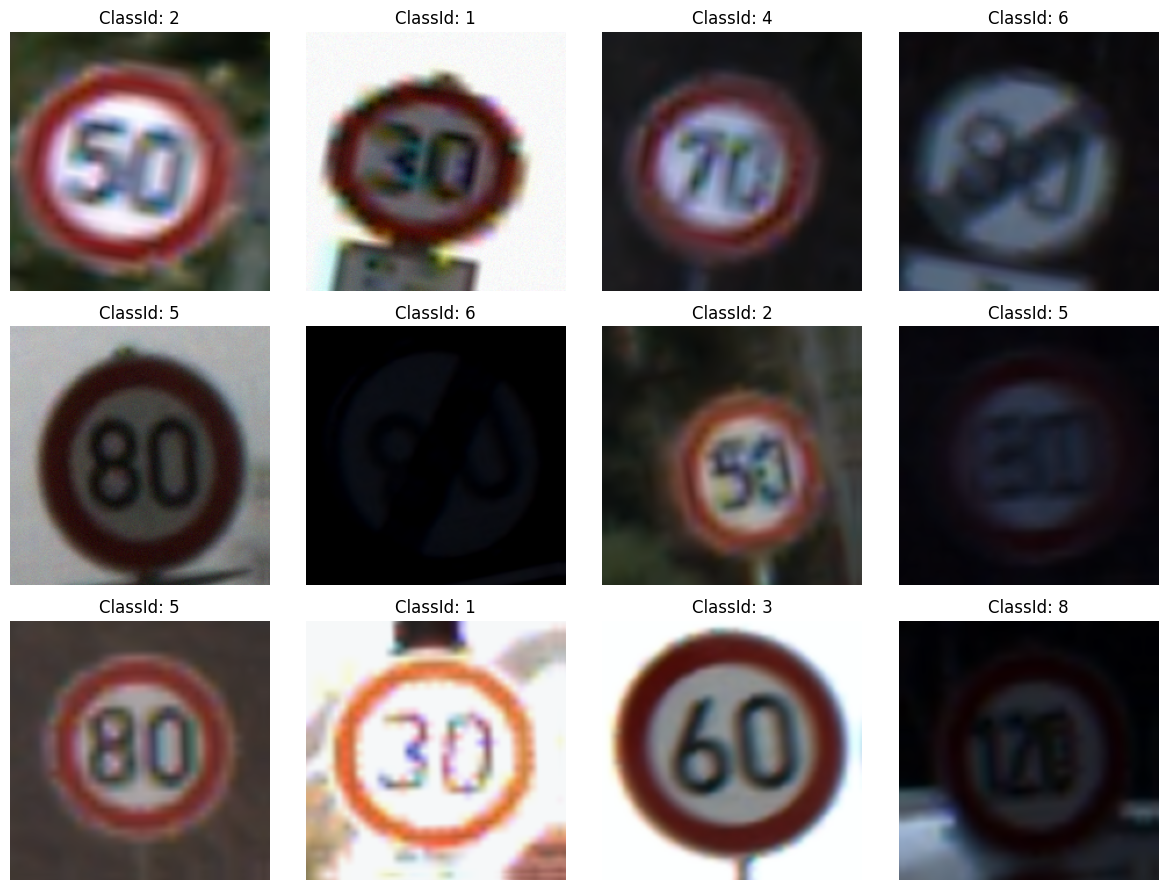

In [19]:
import matplotlib.pyplot as plt
import numpy as np

figure, axes = plt.subplots(
    3,
    4,
    figsize=(12, 9),
)

for index, axis in enumerate(axes.ravel()):
    image = images[index].numpy()

    image = np.clip(
        image,
        0.0,
        1.0,
    )

    axis.imshow(image)
    axis.set_title(
        f"ClassId: {int(labels[index])}"
    )
    axis.axis("off")

plt.tight_layout()
plt.show()

In [20]:
import tensorflow as tf

tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(42)

model = build_custom_cnn(
    input_shape=(224, 224, 3),
    number_of_classes=43,
)

compile_custom_cnn(
    model,
    learning_rate=0.001,
)

model.summary()

Model: "custom_cnn_baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_bn1 (BatchNormalization) │ (None, 224, 224, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_relu1 (Activation)       │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 32)   │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_bn2 (BatchNormalization) │ (None, 224, 224, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_relu2 (Activation)       │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_dropout (Dropout)        │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 64)   │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_bn1 (BatchNormalization) │ (None, 112, 112, 64)   │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_relu1 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 64)   │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_bn2 (BatchNormalization) │ (None, 112, 112, 64)   │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_relu2 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_dropout (Dropout)        │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_bn1 (BatchNormalization) │ (None, 56, 56, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_relu1 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 128)    │       147,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_bn2 (BatchNormalization) │ (None, 56, 56, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_relu2 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_dropout (Dropout)        │ (None, 28, 28, 128)    │             

 Total params: 661,899 (2.52 MB)

 Trainable params: 659,979 (2.52 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [21]:
smoke_history = model.fit(
    train_ds,
    validation_data=validation_ds,

    epochs=1,

    steps_per_epoch=5,
    validation_steps=2,

    class_weight=class_weights,

    verbose=1,
)

2/5 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - loss: 2.4252 - sparse_accuracy: 0.0000e+00 - top3_accuracy: 0.0625 

I0000 00:00:1784668277.685357      66 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


5/5 ━━━━━━━━━━━━━━━━━━━━ 23s 545ms/step - loss: 2.5693 - sparse_accuracy: 0.0688 - top3_accuracy: 0.1437 - val_loss: 3.7703 - val_sparse_accuracy: 0.0000e+00 - val_top3_accuracy: 0.0000e+00


In [22]:
tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(42)

model = build_custom_cnn(
    input_shape=(224, 224, 3),
    number_of_classes=43,
)

compile_custom_cnn(
    model,
    learning_rate=0.001,
)

print(
    "Fresh model parameters:",
    model.count_params(),
)

Fresh model parameters: 661899


In [23]:
from pathlib import Path

OUTPUT_ROOT = Path(
    "/kaggle/working/custom_cnn_outputs"
)

MODEL_DIR = OUTPUT_ROOT / "models"
REPORT_DIR = OUTPUT_ROOT / "reports"
FIGURE_DIR = OUTPUT_ROOT / "figures"
LOG_DIR = OUTPUT_ROOT / "logs"

for directory in [
    MODEL_DIR,
    REPORT_DIR,
    FIGURE_DIR,
    LOG_DIR,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )

print("Results will be saved to:")
print(OUTPUT_ROOT)

Results will be saved to:
/kaggle/working/custom_cnn_outputs


In [24]:
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(
            MODEL_DIR / "best_custom_cnn.keras"
        ),
        monitor="val_loss",
        mode="min",
        save_best_only=True,
        verbose=1,
    ),

    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        mode="min",
        patience=6,
        restore_best_weights=True,
        verbose=1,
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1,
    ),

    tf.keras.callbacks.CSVLogger(
        filename=str(
            LOG_DIR / "training_log.csv"
        ),
        append=False,
    ),

    tf.keras.callbacks.TerminateOnNaN(),
]

print("Callbacks created.")

Callbacks created.


In [25]:
import time

training_start = time.perf_counter()

history = model.fit(
    train_ds,
    validation_data=validation_ds,

    epochs=30,

    class_weight=class_weights,
    callbacks=callbacks,

    verbose=1,
)

training_seconds = (
    time.perf_counter() - training_start
)

print(
    "Training time, minutes:",
    training_seconds / 60,
)

Epoch 1/30
981/981 ━━━━━━━━━━━━━━━━━━━━ 0s 355ms/step - loss: 2.3390 - sparse_accuracy: 0.1354 - top3_accuracy: 0.3500
Epoch 1: val_loss improved from None to 3.45107, saving model to /kaggle/working/custom_cnn_outputs/models/best_custom_cnn.keras

Epoch 1: finished saving model to /kaggle/working/custom_cnn_outputs/models/best_custom_cnn.keras
981/981 ━━━━━━━━━━━━━━━━━━━━ 387s 382ms/step - loss: 3.2186 - sparse_accuracy: 0.1223 - top3_accuracy: 0.3083 - val_loss: 3.4511 - val_sparse_accuracy: 0.0765 - val_top3_accuracy: 0.1899 - learning_rate: 0.0010
Epoch 2/30
981/981 ━━━━━━━━━━━━━━━━━━━━ 0s 310ms/step - loss: 2.1548 - sparse_accuracy: 0.1591 - top3_accuracy: 0.3644
Epoch 2: val_loss did not improve from 3.45107
981/981 ━━━━━━━━━━━━━━━━━━━━ 313s 319ms/step - loss: 2.7719 - sparse_accuracy: 0.1600 - top3_accuracy: 0.3629 - val_loss: 3.9910 - val_sparse_accuracy: 0.0368 - val_top3_accuracy: 0.1692 - learning_rate: 0.0010
Epoch 3/30
981/981 ━━━━━━━━━━━━━━━━━━━━ 0s 310ms/step - loss: 1.9

In [26]:
import pandas as pd
import json

final_model_path = (
    MODEL_DIR / "final_custom_cnn.keras"
)

model.save(final_model_path)

history_frame = pd.DataFrame(
    history.history
)

history_frame.insert(
    0,
    "epoch",
    range(1, len(history_frame) + 1),
)

history_frame.to_csv(
    REPORT_DIR / "training_history.csv",
    index=False,
)

training_summary = {
    "epochs_completed": len(history_frame),
    "training_seconds": training_seconds,
    "training_minutes": (
        training_seconds / 60
    ),
    "best_val_loss": float(
        history_frame["val_loss"].min()
    ),
    "best_val_accuracy": float(
        history_frame[
            "val_sparse_accuracy"
        ].max()
    ),
    "best_val_top3_accuracy": float(
        history_frame[
            "val_top3_accuracy"
        ].max()
    ),
    "total_parameters": int(
        model.count_params()
    ),
}

(
    REPORT_DIR / "training_summary.json"
).write_text(
    json.dumps(
        training_summary,
        indent=2,
    ),
    encoding="utf-8",
)

print("Final model:", final_model_path)
print(training_summary)

Final model: /kaggle/working/custom_cnn_outputs/models/final_custom_cnn.keras
{'epochs_completed': 30, 'training_seconds': 9478.54576656, 'training_minutes': 157.975762776, 'best_val_loss': 0.43629181385040283, 'best_val_accuracy': 0.8829991221427917, 'best_val_top3_accuracy': 0.9602758884429932, 'total_parameters': 661899}


In [27]:
best_model_path = (
    MODEL_DIR / "best_custom_cnn.keras"
)

best_model = tf.keras.models.load_model(
    best_model_path
)

test_evaluation = best_model.evaluate(
    test_ds,
    return_dict=True,
    verbose=1,
)

print("Keras test evaluation:")

for name, value in test_evaluation.items():
    print(
        f"{name}: {value:.6f}"
    )

395/395 ━━━━━━━━━━━━━━━━━━━━ 35s 85ms/step - loss: 0.5588 - sparse_accuracy: 0.8537 - top3_accuracy: 0.9542
Keras test evaluation:
loss: 0.558772
sparse_accuracy: 0.853682
top3_accuracy: 0.954236


In [28]:
import numpy as np

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)


probabilities = best_model.predict(
    test_ds,
    verbose=1,
)

true_labels = np.concatenate(
    [
        labels.numpy()
        for _, labels in test_ds
    ]
)

predicted_labels = np.argmax(
    probabilities,
    axis=1,
)

confidence = np.max(
    probabilities,
    axis=1,
)

top3_classes = np.argsort(
    probabilities,
    axis=1,
)[:, -3:][:, ::-1]

top3_correct = np.any(
    top3_classes
    == true_labels[:, None],
    axis=1,
)

metrics = {
    "accuracy": float(
        accuracy_score(
            true_labels,
            predicted_labels,
        )
    ),

    "macro_precision": float(
        precision_score(
            true_labels,
            predicted_labels,
            average="macro",
            zero_division=0,
        )
    ),

    "macro_recall": float(
        recall_score(
            true_labels,
            predicted_labels,
            average="macro",
            zero_division=0,
        )
    ),

    "macro_f1": float(
        f1_score(
            true_labels,
            predicted_labels,
            average="macro",
            zero_division=0,
        )
    ),

    "weighted_f1": float(
        f1_score(
            true_labels,
            predicted_labels,
            average="weighted",
            zero_division=0,
        )
    ),

    "top3_accuracy": float(
        top3_correct.mean()
    ),
}

print(json.dumps(metrics, indent=2))

395/395 ━━━━━━━━━━━━━━━━━━━━ 16s 38ms/step
{
  "accuracy": 0.8536817102137767,
  "macro_precision": 0.8341974202338868,
  "macro_recall": 0.8143875039501935,
  "macro_f1": 0.8050580967378168,
  "weighted_f1": 0.8561048961165791,
  "top3_accuracy": 0.9542359461599367
}


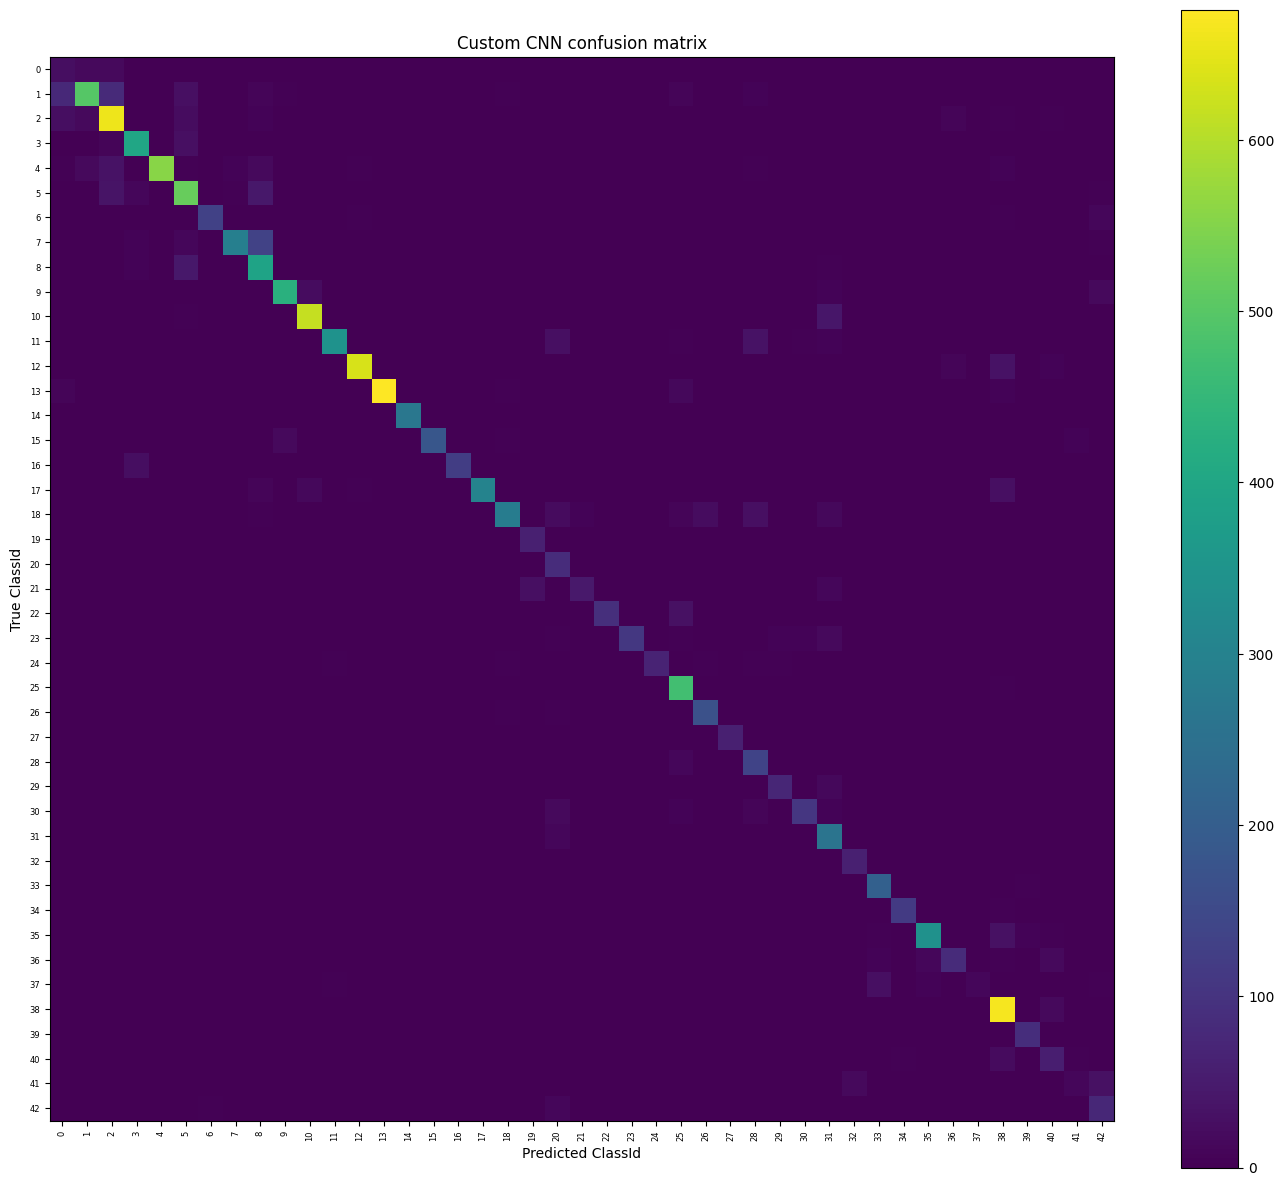

In [29]:
metrics_path = (
    REPORT_DIR / "test_metrics.json"
)

metrics_path.write_text(
    json.dumps(
        metrics,
        indent=2,
    ),
    encoding="utf-8",
)


class_report = classification_report(
    true_labels,
    predicted_labels,
    labels=list(range(43)),
    output_dict=True,
    zero_division=0,
)

class_report_frame = pd.DataFrame(
    class_report
).transpose()

class_report_frame.to_csv(
    REPORT_DIR / "classification_report.csv"
)


confusion = confusion_matrix(
    true_labels,
    predicted_labels,
    labels=list(range(43)),
)

confusion_frame = pd.DataFrame(
    confusion,
    index=[
        f"true_{class_id}"
        for class_id in range(43)
    ],
    columns=[
        f"pred_{class_id}"
        for class_id in range(43)
    ],
)

confusion_frame.to_csv(
    REPORT_DIR / "confusion_matrix.csv"
)


plt.figure(figsize=(14, 12))

plt.imshow(confusion)

plt.colorbar()

plt.xlabel("Predicted ClassId")
plt.ylabel("True ClassId")
plt.title(
    "Custom CNN confusion matrix"
)

plt.xticks(
    range(43),
    rotation=90,
    fontsize=6,
)

plt.yticks(
    range(43),
    fontsize=6,
)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR
    / "custom_cnn_confusion_matrix.pdf",
    bbox_inches="tight",
)

plt.savefig(
    FIGURE_DIR
    / "custom_cnn_confusion_matrix.png",
    dpi=180,
    bbox_inches="tight",
)

plt.show()

In [30]:
import shutil

archive_path = shutil.make_archive(
    base_name=(
        "/kaggle/working/"
        "custom_cnn_results"
    ),
    format="zip",
    root_dir=OUTPUT_ROOT,
)

print("Archive created:")
print(archive_path)

Archive created:
/kaggle/working/custom_cnn_results.zip
